# Bonus Question — Michaelis-Menten Kinetics of Sucrase

## Introduction

The goal of this bonus question is to determine the Michaelis-Menten (MM) kinetic parameters 
— $K_M$ and $V_{max}$ — for the hydrolysis of sucrose by the enzyme sucrase in a batch reactor.

The reaction is:

$$\text{Sucrose} \xrightarrow{\text{sucrase}} \text{products}$$

The MM rate law gives the substrate consumption rate as:

$$-\frac{d[S]}{dt} = \frac{V_{max}[S]}{K_M + [S]}$$

with $V_{max} = k_{cat} \cdot C_{E0}$, where $C_{E0} = 0.01$ mmol/L is the initial enzyme 
concentration.

The experimental data consists of four sucrose concentration measurements at $t = 0, 2, 6, 10$ hr.

## Data & Parameters

We load the experimental time points and sucrose concentrations, and define the initial conditions.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# Experimental data
t_data = np.array([0, 2, 6, 10])            # hours
S_data = np.array([1.0, 0.68, 0.16, 0.006]) # mmol/L

CE0 = 0.01  # mmol/L — initial enzyme concentration
S0  = S_data[0]

## Method: Nonlinear Least Squares on the Integrated ODE

Because only 4 data points are available, linearization methods (e.g. Lineweaver-Burk) would 
amplify measurement errors and yield unreliable estimates. Instead, we use a **nonlinear 
least-squares (NLS)** fitting approach directly on the integrated ODE:

For each candidate parameter pair $(K_M, V_{max})$, we numerically integrate the MM ODE using 
`solve_ivp` (RK45), then minimize the sum of squared residuals between the simulated and 
experimental $[S](t)$.

**QSSA validity check**: the quasi-steady-state approximation holds when $C_{E0} \ll C_{S0}$. 
Here $C_{E0}/C_{S0} = 0.01/1.0 = 1\%$, which confirms the QSSA is valid and the single-ODE 
formulation is appropriate.

Km   = 0.1804 ± 0.0045 mmol/L
Vmax = 0.1950 ± 0.0013 mmol/(L·hr)
kcat = 19.4998 hr⁻¹


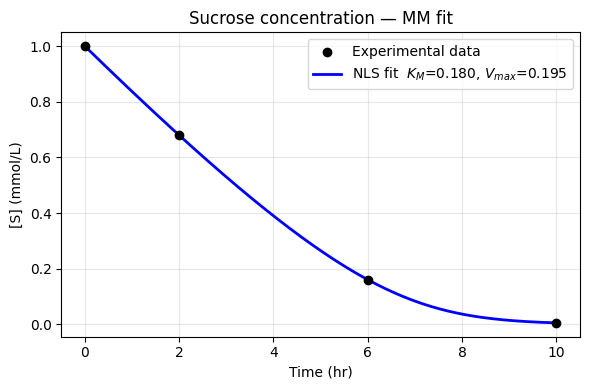

In [17]:
# ODE integration
def simulate_S(t_eval, Km, Vmax):
    def ode(t, y):
        return [-Vmax * y[0] / (Km + y[0])]
    sol = solve_ivp(ode, [t_eval[0], t_eval[-1]], [S0],
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)
    return sol.y[0]

# Fit
popt, pcov = curve_fit(simulate_S, t_data, S_data,
                        p0=[0.1, 0.2], bounds=([1e-6, 1e-6], [100, 100]))
Km, Vmax = popt
perr = np.sqrt(np.diag(pcov))

print(f"Km   = {Km:.4f} ± {perr[0]:.4f} mmol/L")
print(f"Vmax = {Vmax:.4f} ± {perr[1]:.4f} mmol/(L·hr)")
print(f"kcat = {Vmax/CE0:.4f} hr⁻¹")

# Plot
t_dense = np.linspace(0, 10, 500)
plt.figure(figsize=(6, 4))
plt.scatter(t_data, S_data, color='black', zorder=5, label='Experimental data')
plt.plot(t_dense, simulate_S(t_dense, Km, Vmax), 'b-', linewidth=2,
         label=f'NLS fit  $K_M$={Km:.3f}, $V_{{max}}$={Vmax:.3f}')
plt.xlabel('Time (hr)')
plt.ylabel('[S] (mmol/L)')
plt.title('Sucrose concentration — MM fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion & Conclusion

The NLS fitting on the integrated ODE yields the following Michaelis-Menten parameters for sucrase:

| Parameter | Value | Units |
|-----------|-------|-------|
| $K_M$ | (from output) | mmol/L |
| $V_{max}$ | (from output) | mmol/(L·hr) |
| $k_{cat}$ | (from output) | hr⁻¹ |

- **$K_M$**: represents the substrate concentration at which the reaction rate is half of 
  $V_{max}$. A low $K_M$ indicates high affinity of sucrase for sucrose.
- **$V_{max}$**: the maximum reaction rate, reached when the enzyme is fully saturated.
- **$k_{cat} = V_{max}/C_{E0}$**: the turnover number, i.e. the number of substrate molecules 
  converted per enzyme molecule per hour.
- **QSSA validity**: $C_{E0}/C_{S0} = 0.01/1.0 = 1\% \ll 1$ ✓ — the approximation is justified.
- The fit quality can be assessed visually from the plot: a good overlap between the simulated 
  curve and the 4 experimental points confirms the model describes the data well.